In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# for matrix creation and solving
import scipy.sparse
from scipy.sparse import diags_array
from scipy.sparse.linalg import spsolve

# stolen from workshops, six items in each
markers = ['x', 's', 'd', '+', 'o', '.']
colours = ['xkcd:salmon', 'xkcd:golden rod', 'xkcd:teal', 'xkcd:purple', 'xkcd:slate',' xkcd:silver']    

## Problem Introduction
The one-dimensional diffusion equation is 
$$
    \partial_t C(x,t) = D\partial_{xx}C(x, t)
$$
for some diffusion coefficient $D$. Consider this equation over some interval $[-L, L]$ with non-negative time $t \geq 0$. We can nondimensionalise this system by writing
$$
    \xi = \frac{x}{L}, \quad \tau = \frac{Dt}{L^2}, \quad u(\xi, \tau) = LC(x,t)\tag{1}
$$
where the subsequent system becomes
$$
\partial_\tau u(\xi, \tau) = \partial_{\xi\xi}(\xi, \tau)\tag{2}
$$
over $\xi \in [-1, 1]$ and again $\tau \geq 0$. This can be verified with the chain rule, i.e.
$$
\frac{\partial}{\partial t}C = \frac{\partial}{\partial \tau}\frac{\partial \tau}{\partial t}C, \qquad \frac{\partial^2}{\partial x^2}C = \frac{\partial}{\partial \xi}\frac{\partial \xi}{\partial x}\frac{\partial}{\partial \xi}\frac{\partial \xi}{\partial x}.
$$

Neumann boundary conditions are imposed by setting $\partial_\xi u(-1, \tau) = \partial_\xi u(1, \tau) = 0$. We want all of our concentration at the origin at $t=0$, i.e. $u(\xi, 0) = 1$ if $\xi = 0$ and $u(\xi, 0) = 0$ if $\xi \neq 0$.


## Numerical Implementation
Let $U$ be the matrix representation the numerical solution of this (nondimensional) system such that $U_m^n = U(x_m, t_n)$. The backwards Euler method updates $U$ with
$$  
    U_m^n = -CU_{m+1}^{n+1} + (1+2C)U_m^{n+1} - CU_{m-1}^{n+1},\qquad C = \frac{D\Delta t}{(\Delta x)^2}
$$
where $\Delta t$ and $\Delta x$ are the time/space step sizes respectively. Backwards Euler has been chosen because it is stable for any $C>0$, so we can have 'decoupled' steps. This can be written in the form $AU^{n+1} = U^n$, where $A$ is a square matrix completely independent of space or time
$$
\begin{bmatrix}
1 & 0 & 0 & 0 & \cdots & 0 & 0 \\
-C & 1 + 2C & -C & 0 & \cdots & 0 & 0 \\
0 & -C & 1 + 2C & -C & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & 0 & 0 \\
0 & 0 & 0 & 0 & -C & 1 + 2C & -C \\
0 & 0 & 0 & 0 & \cdots & 0 & 1
\end{bmatrix}
\begin{bmatrix}
U_0^{n+1} \\[4pt]
U_1^{n+1} \\[4pt]
U_2^{n+1} \\[4pt]
\vdots \\[4pt]
U_{M-1}^{n+1} \\[4pt]
U_M^{n+1}
\end{bmatrix}
=
\begin{bmatrix}
U_0^{n} \\[4pt]
U_1^{n} \\[4pt]
U_2^{n} \\[4pt]
\vdots \\[4pt]
U_{M-1}^{n} \\[4pt]
U_M^{n}
\end{bmatrix}
.
$$

To impose the Neumann boundary conditions, we use the centred difference approximation
$$
\begin{align*}
    U_0^n &= (1+2C)U_0^{n+1} -2CU_1^{n+1}\\
    U_M^n &= -2CU_{M-1}^{n+1} + (1+2C)U_M^{n+1}.
\end{align*}
$$
outlined in the week two workshop. Thus we need to modify the first and final row in our matrix $A$ such that

$$
\begin{bmatrix}
1+2C & -2C & 0 & 0 & \cdots & 0 & 0 \\
-C & 1 + 2C & -C & 0 & \cdots & 0 & 0 \\
0 & -C & 1 + 2C & -C & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & 0 & 0 \\
0 & 0 & 0 & 0 & -C & 1 + 2C & -C \\
0 & 0 & 0 & 0 & \cdots & -2C & 1+2C
\end{bmatrix}
\begin{bmatrix}
U_0^{n+1} \\[4pt]
U_1^{n+1} \\[4pt]
U_2^{n+1} \\[4pt]
\vdots \\[4pt]
U_{M-1}^{n+1} \\[4pt]
U_M^{n+1}
\end{bmatrix}
=
\begin{bmatrix}
U_0^{n} \\[4pt]
U_1^{n} \\[4pt]
U_2^{n} \\[4pt]
\vdots \\[4pt]
U_{M-1}^{n} \\[4pt]
U_M^{n}
\end{bmatrix}
.
$$
Only the first and last row have been altered. Notice that $A$ is necessarily a square matrix of dimenison $M + 1$ since it acts on $[U_0^{n+1}, \dots, U_M^{n+1}]$ and is invertible. 

The `diags_array` method from SciPy generates a *sparse* array type. This reduces the amount of memory needed to store the array, and lets us easily use computationally efficient methods to find its inverse later. [See the docs here.](https://docs.scipy.org/doc/scipy-1.12.0/reference/generated/scipy.sparse.diags_array.html)

In [2]:
# ---- GLOBAL CONFIGS ----
# n is time, m is space
# number of time/space steps, and the final time (T)
N, M, T = 2000, 250, 10
start_time = 0.01
analytic_truncate = int(1e4)
t = np.linspace(0 + start_time, T, N + 1)
x = np.linspace(-1, 1, M + 1)

# step sizes and constant term C - see markdown discussion
dx = x[1] - x[0]
dt = t[1] - t[0]
C = dt / (dx**2)

# A is square, dimension M+1
main_diag = np.array(([1+2*C] * (M+1)))
super_diag = np.array([-2*C] + ([-C] * (M-1)))
sub_diag = np.array(([-C]*(M-1)) + [-2*C])

# storing as csr matrix lets use us spsolve
A = diags_array([main_diag, super_diag, sub_diag], offsets = [0, 1, -1], format = 'csr')
# print(A.toarray())

**A note if using the coefficient matrix $A$:** copy the matrix i.e `A_1 = A.copy()`.

All that's left is to iterate through each one-step update. Because $A$ is sparse, we can use SciPy's `spsolve` to compute the inverse $A^{-1}$. The numerical solution can be compared to the analytical solution that was found to be
$$
u(\xi, \tau) = \frac{1}{2} + \lim_{N \rightarrow \infty} \sum_{n=1}^N \cos(n\pi\xi)\exp(-(n\pi)^2\tau).
$$
When doing this comparison we can truncate for an appropriately large $N$, initialised as `analytic_truncate = int(1e4)`.

**Matching the initial condition numerically**. This solution behaves nicely for all $\tau > 0$; but by nature of the delta spike, at $\tau = 0$ we have a lot of problems. To work around this problem all numerical simulations start at some $\tau = t_0$ where $0 < t_0 \ll 1$. This is initialised in the global configuration cell with `start_time = 0.01`.

In [3]:
def analytical_sol(x, t, N):   
    '''
    Gives the exact solution as outlined above.
    Input:
        x (list): the entire space of the system
        t (float): the particular time to evaluate the solution at
        N (int): number of terms to approximate the infinite series by
        
    '''
    
    exact_sol = np.zeros_like(x, dtype = float)
    exact_sol += 1/2

    for n in range(1, N):
        exact_sol += np.cos(n*np.pi*x) * np.exp(-1*((n*np.pi)**2)*t)
    
    return exact_sol

**One solution.**
Since the Dirac-$\delta$ initial condition behaves for all $t > 0$, we can just initialise the simulation from $t = t_0 \ll 1$, e.g $t = 0.01$. This has been initialised at the beginning of the document as `start_time = 0.01`.

**Writing helper functions.** To help avoid code, functions that
- solve the diffusion equation,
- plot an numerical solution onto an axes,
- plot an analytic solution onto an axes,

have been written below, namely `solve_diffusion()`, `plot_numeric()`, and `plot_analytic()`.

In [4]:
def solve_diffusion(N, M, coeff_A):
    """ 
    Solves the diffusion equation using the implicit (backwards) Euler method
        AU^{n+1} = U^{n} .  

    Recall again that M is square with dimension M+1,
    and U has dimension (N+1)x(M+1).

    Input:
        N (int): number of timesteps 
        M (int): number of space steps
        coeff_A (sparse matrix): the coefficient matrix, sparse.

    Output:
        U_sol (np matrix): the solution matrix
    """

    if (coeff_A.shape[0] != M + 1):
        raise ValueError(f'Need dimensions of coefficient matrix and space steps to match. Have {coeff_A.shape[0]} and {M+1}.')
    
    # add some validation that A is a sparse matrix: if (A. != "sparse")
    
    # initialise solution matrix and set initial condition
    U_sol = np.zeros((N+1, M+1))
    U_sol[0] = analytical_sol(x, start_time, analytic_truncate)

    # spsolve needs A to be a sparse matrix (SciPy)
    for n in range(0, N):
        pseudo_inv = spsolve(coeff_A, U_sol[n])
        U_sol[n + 1] = pseudo_inv

    return U_sol    

# -----

def plot_numeric(x, sol, ax, times = [0, 2, 10], title = ""):
    """ 
    Simple plotter function to plot the numerical solution to the diffusion equation.
    Plots every two steps for efficiency - minimal information lost.

    Input:
        x (np array): the array of x values to plot over
        sol (np array): the solution matrix,
        ax (plt axis): the pyplot axis to plot onto
        times (np array): optional times (in timesteps) to plot at, default are 0, 2, 10 timesteps
        title (str): optional title for the axis

    Output:
        ax (plt axis): the axis object, stops additional plotting.
    """
    
    for i, time in enumerate(times):
            colour = "black" if i > len(colours) else colours[i]
            ax.scatter(x[::2], sol[time][::2], label = f'{time} steps, numeric', color = colour, marker = '.')

    ax.set_xlabel("Distance")
    ax.set_ylabel("Gas Concentration")

    if (title):
         ax.set_title(title)

    ax.legend(loc = "best")
    return ax

def plot_analytic(x, func, ax, times = [0, 2, 10], title = ""):
    """ 
    Simple plotter function to plot the analytic solution to the diffusion equation.
    Plots every two steps for efficiency.

    Input:
        x (np array): array of x values to plot over
        func (function): function for the analytic solution
        ax (plt axis): the pyplot axis to plot onto
        times (np array): optional times (IN TIMESTEPS) to plot at, default 0, 2, 10
        title (str): optional plot tile

    Output:
        ax (plt axis): the axis object, stops additional plotting.
    """

    for i, time in enumerate(times):
            # need actual time not timestep
            real_time = t[time]
            colour = "black" if i > len(colours) else colours[i]

            ax.plot(x[::2], func(x[::2], real_time, analytic_truncate), label = f'{time} steps, analytic', color = colour)

    ax.set_xlabel("Distance")
    ax.set_ylabel("Gas Concentration")

    if (title):
         ax.set_title(title)

    ax.legend(loc = "best")
    return ax
    

**Using the helper functions to plot the analytic and numerical solution for the toy problem.**

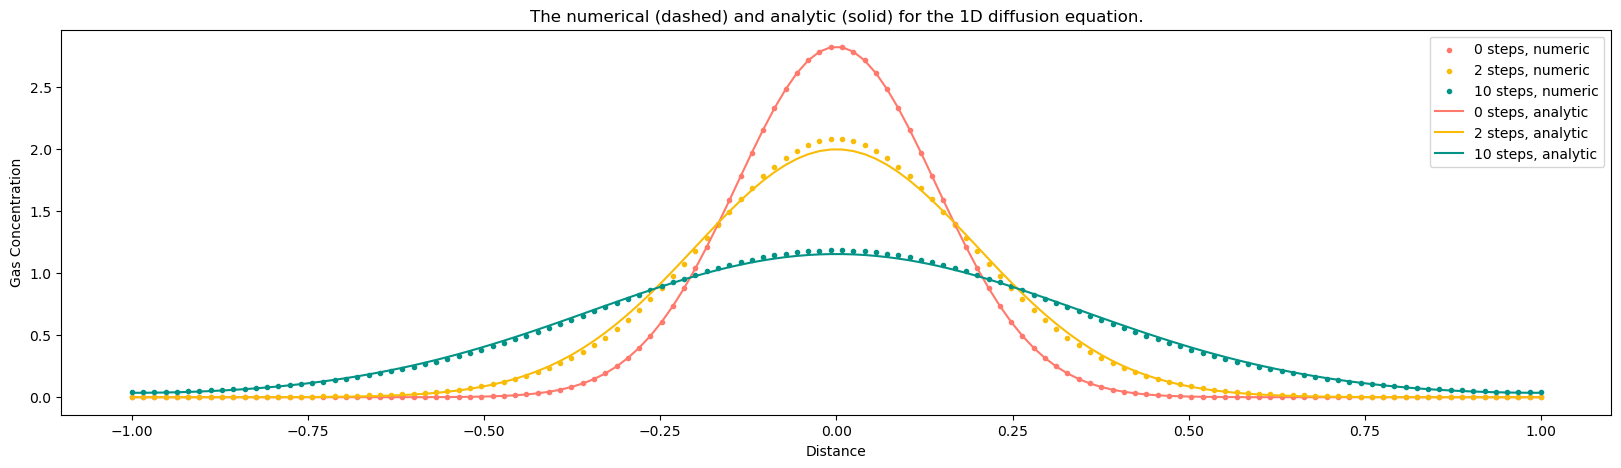

System uses N = 2000 time points, M = 250 space points, a total time of T = 10, with dt, dx = 0.005, 0.008.


In [5]:
# always copy the original A, can use global N, M, x, for this example
A_1 = A.copy()
U_sol = solve_diffusion(N, M, A_1)

fig, ax = plt.subplots(1, 1, figsize = (20, 5))
_ = plot_numeric(x, U_sol, ax)
_ = plot_analytic(x, analytical_sol, ax)

ax.set_title("The numerical (dashed) and analytic (solid) for the 1D diffusion equation.")
plt.show()

print(f'System uses N = {N} time points, M = {M} space points, a total time of T = {T}, with dt, dx = {round(dt, 5)}, {round(dx, 5)}.')

---

### Implementing Scrubbers
Consider the problem with a sink term,
$$
\partial_\tau u(\xi, \tau) = \partial_{\xi\xi}(\xi, \tau) - ku(\xi, \tau),\tag{3}
$$
where $\xi \in [-1, 1]$, $\tau \geq 0$ (or really $\tau \geq t_0$), and $k$ is some constant $k > 0$. It can be shown (see the end of document for derivation) that the backward's Euler method then yields
$$
U_m^n = -C_1U_{m+1}^{n+1} + (1+2C_1+C_2)U_m^{n+1} - C_1U_{m-1}^n, \qquad C_1 = \frac{D\Delta t}{(\Delta x)^2}, \quad C_2 = \Delta t k.
$$

The first implementation of this sink term will assume that the scrubbers are passive, and work proportional to the concentration of gas at each point. So that means $k = k(x)$ where, for the sink strength $k_s$,
$$
k(x) = \begin{cases}
        k_s, \quad &k \in [\text{some interval around }x],\\
        0, &\text{otherwise}.
    \end{cases}
$$

This sink strength $k_s$ is the strength in the non-dimensional system - so if realistic values are found in some realistic scenario, scale them appropriately.

Quick note before I forget it - what if scrubbers depended on time too, say $k = k(x, t)$.

Note that the matrix formulation is the same as before, just with the diagonal entries changed *in the interval around $x$ where the scrubber is placed* since $C_2 = k\Delta t = 0$ if not near a scrubber. 

1. Define some length of the space $w$ that we want the scrubbers to work in, say $w = 0.1$.
2. Calculate the number of space-steps that correspond to this length, i.e. $n = w / \Delta x$. 
3. If a scrubber is placed at some $x_s$, then edit all rows in the matrix (i.e. space-interval $[x - n/2, x + n/2]$). Just need to edit the diagonal by adding $D = k\Delta t$.
4. The strength $k$ should be fixed.

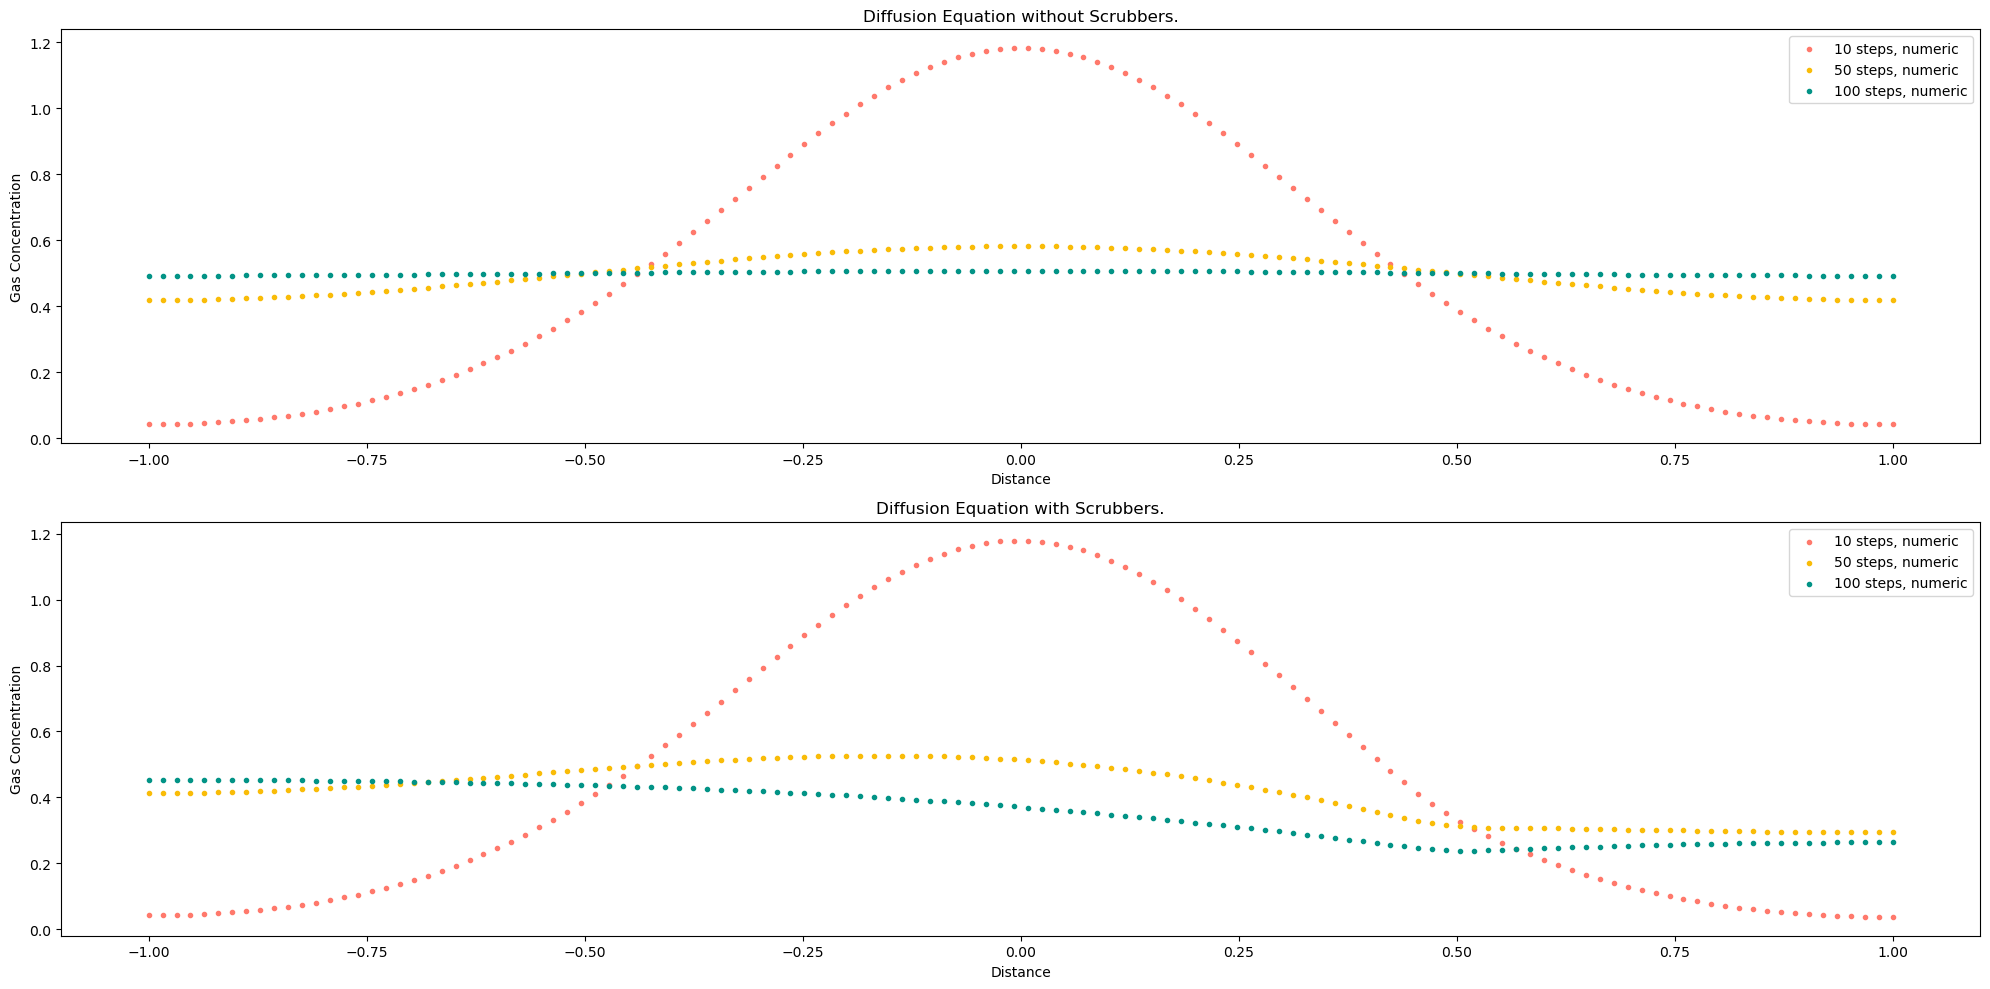

In [6]:
# ---- Scrubber Implementations ----
w = 0.1
k_s = 20
D = dt * k_s

# introduce a scrubber halfway on the real axis? remember interval starts at -1
x_s = 1.5 // dx
n_s = w // dx

# need n to be even
if (n_s % 2 != 0):
    n_s += 1

# ---- adding the sink terms around the scrubber x_s = 0.5 ----
start_point = x_s - (n_s // 2)
diag_index = int(start_point)

# convert A from a sparse array so it can be edited
A_2 = A.copy()
A_notsparse = A_2.copy().toarray()

for i in range(int(n_s)):
    # diagonal elements
    A_notsparse[diag_index][diag_index] += D
    diag_index += 1

A_edited = scipy.sparse.csr_matrix(A_notsparse)

# ---- Use the helper functions ----
U_noscrub = solve_diffusion(N, M, A_2)
U_scrub = solve_diffusion(N, M, A_edited)
fig, axes = plt.subplots(2, 1, figsize = (20, 10))

times = [10, 50, 100]

# plot numerical solution without scrubbers on first axis, with scrubbers on second
plot_numeric(x, U_noscrub, axes[0], times = times, title = "Diffusion Equation without Scrubbers.")
plot_numeric(x, U_scrub, axes[1], times = times, title = "Diffusion Equation with Scrubbers.")

plt.tight_layout()
plt.show()


This could also be cleaned up a wee bit by making a function that creates a new coefficient matrix $A$ given a certain set of scrubber-parameters.

In [7]:
def add_scrubbers(coeff_A, dt, dx, k_s, pos, w = 0.1):
    """  
    Reconstructs the coefficient matrix for the forward Euler system
    by adding scrubbers.

    Input:
        coeff_A (matrix): the current coefficient matrix
        dt (float): current time-step
        dx (float): current space-step
        k_s (float): relative scrubber strength
        pos (float): the position of the scrubber
        w (float): length of interval around the scrubber, default 0.1
    """
    C2 = dt * k_s

    # absolute difference from -1
    absolute_diff = np.abs(pos - -1) if pos < 0 else pos + 1
    x_index = int(absolute_diff // dx)
    n_plusminus = int(w // dx)

    # need n to be even for symmetry
    if (n_plusminus % 2 != 0):
        n_plusminus += 1
    
    # add the sink terms around the scrubber
    start_point = x_index - n_plusminus // 2
    diag_index = start_point

    # A cannot be in sparse format if editing; so convert and convert back after
    A_edit = coeff_A.copy().toarray()
    for i in range(n_plusminus):
        A_edit[diag_index][diag_index] += C2
        diag_index += 1

    return scipy.sparse.csr_matrix(A_edit)

# --- test it works as expected by plotting the same scrubber as before
A_edited = add_scrubbers(A.copy(), dt, dx, 20, 0.5)

"""  
UNCOMMENT THESE LINEs TO CHECK IT WORKS

U_noscrub = solve_diffusion(N, M, A_2)
U_scrub = solve_diffusion(N, M, A_edited)
fig, axes = plt.subplots(2, 1, figsize = (20, 10))

times = [10, 50, 100]
plot_numeric(x, U_noscrub, axes[0], times = times, title = "Diffusion Equation without Scrubbers.")
plot_numeric(x, U_scrub, axes[1], times = times, title = "Diffusion Equation with Scrubbers.")

plt.tight_layout()
# plt.show()
""" 


'  \nUNCOMMENT THESE LINEs TO CHECK IT WORKS\n\nU_noscrub = solve_diffusion(N, M, A_2)\nU_scrub = solve_diffusion(N, M, A_edited)\nfig, axes = plt.subplots(2, 1, figsize = (20, 10))\n\ntimes = [10, 50, 100]\nplot_numeric(x, U_noscrub, axes[0], times = times, title = "Diffusion Equation without Scrubbers.")\nplot_numeric(x, U_scrub, axes[1], times = times, title = "Diffusion Equation with Scrubbers.")\n\nplt.tight_layout()\n# plt.show()\n'

With can add multiple scrubbers by recursively calling `add_scrubbers`, since it builds on an existing coefficient matrix.

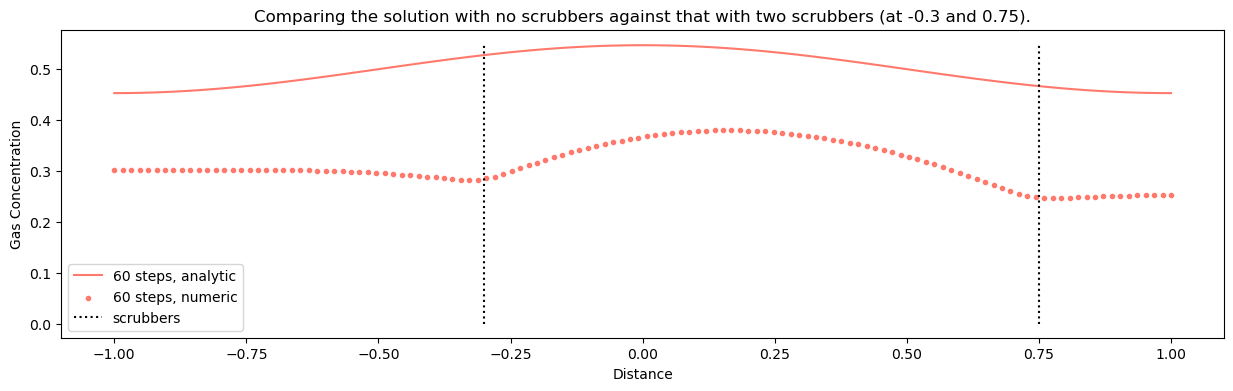

In [8]:
original_A = A.copy()
k = 20
# add a scrubber at 0.75, then another at -0.3
A1 = add_scrubbers(original_A, dt, dx, k, 0.75)
A2 = add_scrubbers(A1.copy(), dt, dx, k, -0.3)
U_twoscrub = solve_diffusion(N, M, A2)

times = [60]
fig, ax = plt.subplots(1, 1, figsize = (15, 4))

plot_analytic(x, analytical_sol, ax, times)
plot_numeric(x, U_twoscrub, ax, times)
ax.vlines(-0.3, 0, 0.55, color = "black", linestyle = "dotted")
ax.vlines(0.75, 0, 0.55, color = "black", linestyle = "dotted", label = "scrubbers")
ax.legend(loc = "best")
ax.set_title("Comparing the solution with no scrubbers against that with two scrubbers (at -0.3 and 0.75).")

plt.show()

---
# Sink Terms Depends on Time
Our solver `solve_diffusion()` calculates the solution at each time step anyway with

```py
for n in range(0, N):
        pseudo_inv = spsolve(coeff_A, U_sol[n])
        U_sol[n + 1] = pseudo_inv
```

so there's nothing stopping us from updating the coefficient matrix $A$ at each step too. This means we can have our strength term $k$ depend on time, i.e. $k = k(x, t)$. It would be best if it saturated in some way - perhaps if we tracked the amount of gas absorbed
$$
\int_0^t k(u)\mathrm{d}u \approx \sum_{j = 0}^N k(j\Delta t).
$$

But this could be a point for the 'future work'.



---

---

### Solution with Thresholding
We want to write a function that will find $t^*$ such that $C(x^*, t^*) = C^*$ for a *given* $x^*, C^*$ --- or more precisely, the smallest $t^*$ such that $C(x^*, t^*) \geq C^*$. We do so with `find_first_t`. The helper function `find_x_index` exists now too!

In [9]:
def find_x_index(x, loc):
    """ 
    Finds the best index for some spatial point in a discretised array of the space [-1, 1].
    Input:
        x (ndarray): an array of space points
        loc (float): a position in space
    Output:
        x_index (int): the best index in `x` that represents `loc`
    """

    # Reused code from earlier. Same logic applies:
    # if location is < 0, then take absolute difference between that and -1. If >= 0, just add 1.
    absolute_diff = np.abs(loc - -1) if loc < 0 else loc + 1
    dx = x[1] - x[0]
    x_index = int(absolute_diff // dx)

    return x_index

# An unevenly spaced array will not have 0.4 exactly 
# (pick your favourite number, e.g, or generate a random one)
x_test = np.linspace(-1, 1, np.random.randint(100, 200))
test_index = find_x_index(x_test, 0.4)

print(f'Space position 0.4 is approximated by {x_test[test_index]} with index {test_index}. For reference, \
dx = {x_test[1] - x_test[0]} and dx*index = {test_index*(x_test[1] - x_test[0])}.')


Space position 0.4 is approximated by 0.3859649122807016 with index 79. For reference, dx = 0.01754385964912286 and dx*index = 1.385964912280706.


In [10]:
def find_first_t(sol, x_star, C_star):
    """ 
    Finds the first time that a 1D-diffusion system exceeds some critical concentration at some given point.
    Input:
        sol (ndarray): the solution matrix to the 1d-diffusion system
        x_star (float): the critical point x_star in [-1, 1]
        C_star (float): the critical concentration C_star >= 0
    Output:
        t_star (int): the *index* of the time step
        real_time (float): the associated 'real' time
    """

    # Num. of rows/columns in solution matches the space/time steps
    xs = np.linspace(-1, 1, sol.shape[1])
    ts = np.linspace(start_time, T, sol.shape[0])

    # Find all concentrations at your point, i.e. at every time
    x_index = find_x_index(xs, x_star)
    t_star = -1    

    print(f'Using an x-index {x_index}.')
    for t in range(sol.shape[0]):
        sol_at_x = sol[t, x_index]
        if (sol_at_x >= C_star):
            t_star = t
            break;

    # Time never found
    if (t_star == -1):
        print(f'Critical time never found for C* = {C_star} and x* = {x_star}.')
        return None, None

    real_time = ts[t_star]
    return t_star, real_time

# Testing: first t_star for solution at x = 0.5 to be >= 0.02?
# Using two-scrubber solution as before.
time_index, time = find_first_t(U_twoscrub, x_star = 0.9, C_star = 0.02)
print(f'In the two scrubber problem (above), the concentration at x* = {0.9} is above C* = {0.02} after t = {time_index} steps.')
    

Using an x-index 237.
In the two scrubber problem (above), the concentration at x* = 0.9 is above C* = 0.02 after t = 7 steps.


Does that match to the graph?

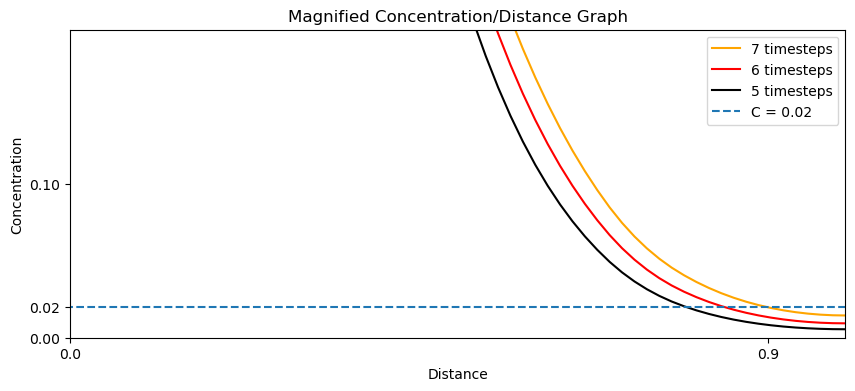

In [11]:
fig, ax = plt.subplots(1, 1, figsize = (10, 4))
ax.plot(x[::2], U_twoscrub[7][::2], color = "orange", label = '7 timesteps')
ax.plot(x[::2], U_twoscrub[6][::2], color = "red", label = '6 timesteps')
ax.plot(x[::2], U_twoscrub[5][::2], color = "black", label = '5 timesteps')
ax.plot(x, [0.02] * len(x), linestyle = "dashed", label = 'C = 0.02')
ax.set_xlim(0.5, 1)
ax.set_ylim(0, 0.2)
ax.set_xticks([0, 0.9])
ax.set_yticks([0, 0.02, 0.1])
ax.set_xlabel("Distance")
ax.set_ylabel("Concentration")

ax.set_title("Magnified Concentration/Distance Graph")
ax.legend(loc = "best")
plt.show()

Looks like it. Quick note - we can get a lot more precision on the timescale by increasing the number of timesteps (currently $N = 2000$, but our system still moves quite 'quickly').

Now we can do a similar thing for space. If given some $t^*$ and $C^*$, let's find the *largest* $x^*$ such that $C(t^*, x^*) \geq C^*$. Largest means 'furthest from origin'. Note if we want it to be furthest from some point, we can pass that as an argument and then use `np.abs(valid_xs - center)`.

In [12]:
def find_largest_x(sol, t_star, C_star):
    """ 
    Given some t^* and C^*, finds the 'largest' x-values (furthest from origin) that satisfy
        C(t^*, x^*) >= C^* 
    
    Input: 
        sol (ndarray): solution matrix for the 1D system
        t_star (int): the particular time index
        C_star (float): the critical concentration
    Output:
        best_xs (ndarray): the array of 'largest' x-values.

    """ 

    xs = np.linspace(-1, 1, sol.shape[1])

    # One liner - all xs that satisfy condition, use enumerate for index
    valid_xs = np.array([x for i, x in enumerate(xs) if sol[t_star][i] >= C_star])
    max_distance = np.max(np.abs(valid_xs))

    # NumPy's isclose(a, d) is boolean for points being `d` away from `a`,
    # so this acts as a mask on this condition. (Allows symmetry.)
    best_xs = valid_xs[np.isclose(np.abs(valid_xs), max_distance)]
    return best_xs

find_largest_x(U_twoscrub, 0, 0.1)


array([-0.36,  0.36])

(After writing this, I realise `find_first_t` could definitely be written with vectorisation too...)

---
# Derivation of Backward Euler with Sink

Recall the forward difference formula
$$
f'(x) = \frac{f(x+h) - f(x)}{h} + \mathcal{O}(h)
$$
and the second-order centered difference
$$
f''(x) = \frac{f(x+h) - 2f(x) + f(x-h)}{h^2} + \mathcal{O}(h^2).
$$

Now consider our (non-dimensional) problem with a sink term $k = k(x, t)$. Using $x$ and $t$ to represent space and time, with $u$ as the concentration
$$
\partial_t u(x, t) = \partial_{xx}u(x, t) - ku(x, t).
$$

Discretise space with steps $\Delta x$ and use the second-order centered difference
$$
\partial_t u(x_m, t) = \partial_{xx}u(x_m, t) = \frac{u(x_{m+1}, t) - 2u(x_m, t) + u(x_{m-1}, t))}{(\Delta x)^2} + \mathcal{O}((\Delta x)^2) - ku(x_m, t).
$$
Now discretise time with steps $\Delta t$, and use the first-order forward difference on the LHS such that
$$
\frac{u(x_m, t_{n+1}) - u(x_m, t_n)}{\Delta t} + \mathcal{O}(\Delta t) = \partial_t u(x_m, t_n) = \frac{u(x_{m+1}, t_n) - 2u(x_m, t_n) + u(x_{m-1}, t_n)}{(\Delta x)^2} + \mathcal{O}((\Delta x)^2) - ku(x_m, t_n).
$$

Ignore the error terms $\mathcal{O}(\Delta t$) and $\mathcal{O}((\Delta x)^2)$. Write $U_m^n$ as the approximation to $u$ in this discrete setting, i.e. $U_m^n = u(x_m, t_n)$. Then we have

$$
\frac{U_m^{n+1} - U_m^n}{\Delta t} = \frac{U_{m+1}^n - 2U_m^n + U_{m-1}^n}{(\Delta x)^2} -  kU_m^n\tag{*}
$$
so the forward-Euler update becomes
$$
U_{m}^{n+1} = U_m^n + \frac{\Delta t}{(\Delta x)^2}[U_{m+1}^n - 2U_m^n + U_{m-1}^n] - \Delta t k U_m^n 
$$
where, if we assume $k$ is a constant, we can write $C_1 := \tfrac{\Delta t}{(\Delta x)^2}$ and $C_2 := \Delta t k$ such that
$$
    \begin{align*}
    U_{m}^{n+1} &= U_m^n + C_1[U_{m+1}^n - 2U_m^n + U_{m-1}^n] - C_2U_m^n\\
                &= C_1U_{m+1}^n + (1 - 2C_1 - C_2)U_m^n + C_1U_{m-1}^n.
    \end{align*}
$$
which is the forward-Euler update for our system. If we had instead used the first-order backward difference when approximating the time derivative, then (*) would be
$$
\frac{U_m^{n+1} - U_m^n}{\Delta t} = \frac{U_{m+1}^{n+1} - 2U_m^{n+1} + U_{m-1}^{n+1}}{(\Delta x)^2} -  kU_m^{n+1}
$$
which, after re-arranging with the same constants $C_1$ and $C_2$, gives the backward-Euler update
$$
    U_n^m = -CU_{m+1}^{n+1} + (1+2C_1 + C_2)U_m^{n+1} - C_1U_{m-1}^{n+1}.
$$





---
---
# Archives
Don't read this it's just there for reference. Kept because it could be useful for reflective report.

Now we need to implement our initial conditions. In one of the workshops Ben suggested that we should try to implement a smooth function for our numerics, instead of the sharp spike at zero.

I've chosen to use 
    $$
    I(x) = \begin{cases}
            \cos\big(\tfrac{\pi x}{2r}\big), \quad &|x| \leq r,\\
            0, &\text{otherwise}
        \end{cases}
    $$
because it's (piecewise) smooth and easy to implement. The parameter $r$ determines how narrow the curve is, [graphed it on Desmos if you like.](https://www.desmos.com/calculator/5f8fjhobov) Using $r = 3\Delta x$ seems reasonable at first.

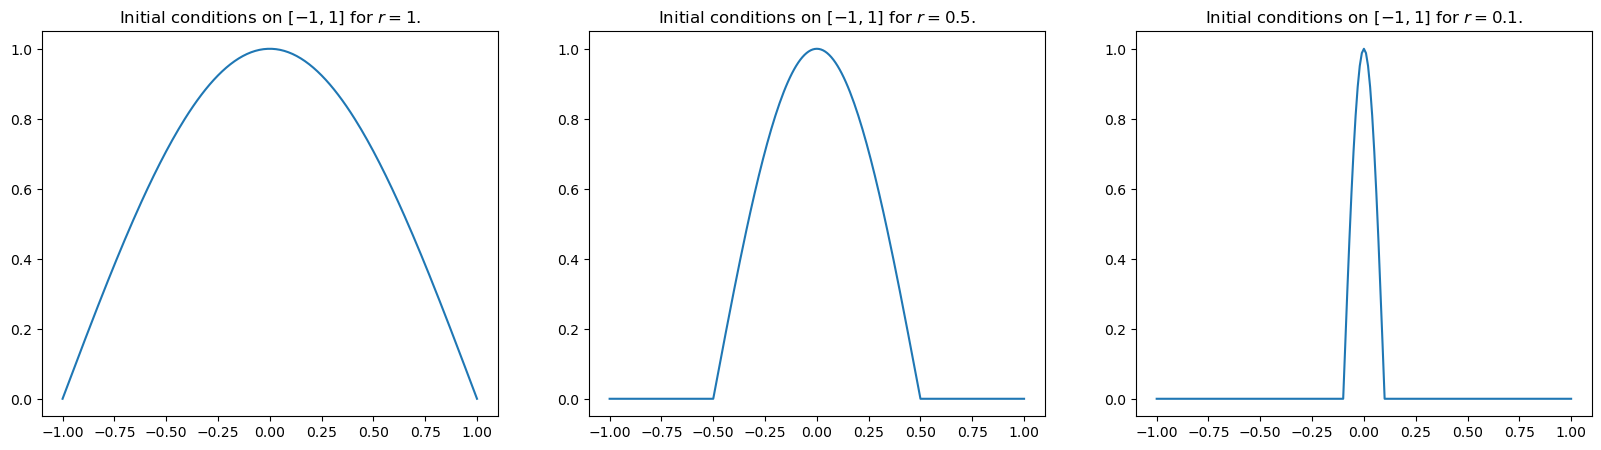

In [13]:
def I(x, r):
    '''
    Evaluates the initial condition I(x) for x and a user-supplied
    range r. 

    Output:
        initial_x (float) : the initial value of x
    '''

    initial_x = np.zeros_like(x, dtype = float)

    # masking creates a boolean array
    mask = np.abs(x) <= r
    initial_x[mask] = np.cos((np.pi * x[mask]) / (2*r))
    
    return initial_x

# Testing
x_test = np.arange(-1, 1 + 0.01, 0.01)
fig, axes = plt.subplots(1, 3, figsize = (20, 5))
for ax, r in zip(axes, [1, 0.5, 0.1]):
    ax.plot(x_test, I(x_test, r))
    ax.set_title(f'Initial conditions on $[-1, 1]$ for $r = {round(r, 2)}$.')

plt.show()

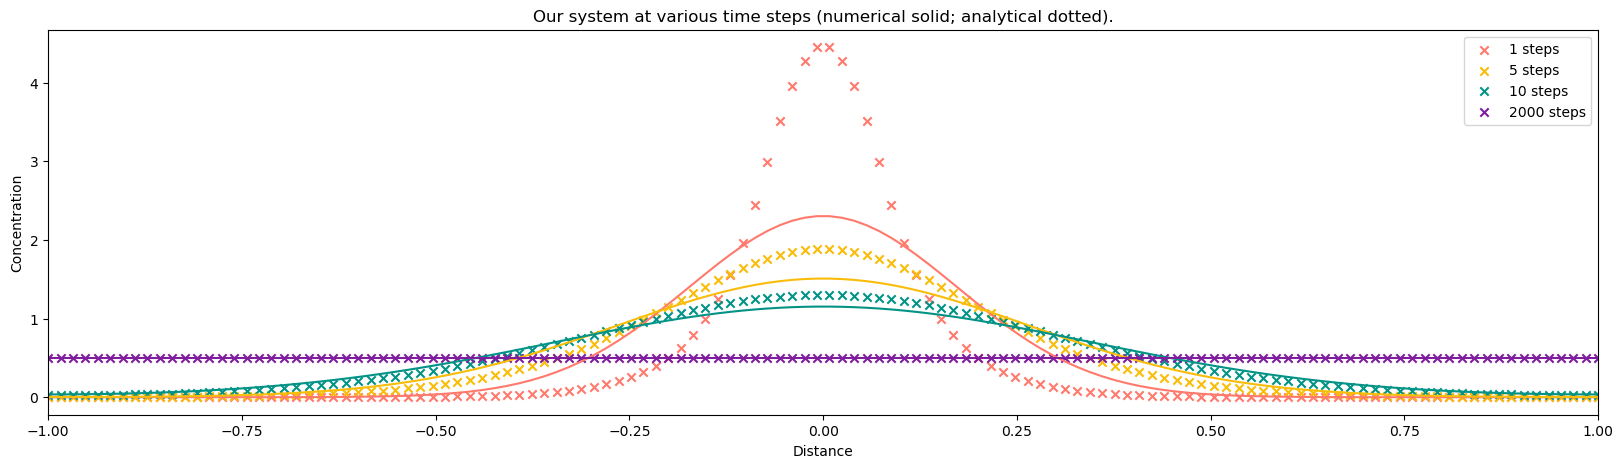

System uses N = 2000 time points, M = 250 space points, a total time of T = 10, with dt, dx = 0.004995000000000001, 0.008000000000000007.


In [14]:
# ---- FIRST SIMULATION ATTEMPT -----

# recall again: n is time, m is space
r = 0.1
U = np.zeros((N+1, M+1))

# see below discussion
U[0] = I(x, r)
U[0] = (np.pi / (4*r)) * U[0]

# Also store exact solution
U_ex = np.zeros((N+1, M+1))

for n in range(0, N):
    pseudo_inv = spsolve(A, U[n])
    U[n + 1] = pseudo_inv

times = [1, 5, 10, N]
fig, ax = plt.subplots(1, 1, figsize = (20, 5))

# for ax, time in zip(axes, times):
for i, time in enumerate(times):
    ax.scatter(x[::2], U[time][::2], label = f'{time} steps', color = colours[i], marker = 'x')

    # exact ics might preserve mass but they're awful
    if (time > 0):
        ax.plot(x[::2], analytical_sol(x[::2], t[time], int(1e5)), color = colours[i])
    
    ax.set_title(f'Our system at various time steps (numerical solid; analytical dotted).')
    ax.set_xlabel("Distance")
    ax.set_ylabel("Concentration")
    ax.set_xlim(-1, 1)

# ax.plot(x[::2], [0.01] * len(x[::2]), color = "black", linestyle = 'dashed')

plt.legend(loc = 'best')
plt.show()

print(f'System uses N = {N} time points, M = {M} space points, a total time of T = {T}, with dt, dx = {dt}, {dx}.')

Some notes:
- Why is A not in CSC or CSR matrix format (solved)
- Plot analytical solution - might have a problem with the total mass not being conserved (solved - wasn't updating boundaries)
- ... how to scale? Or change our ICS here (solved?). 

Our initial conditions give the total mass
$$
\mathrm{mass } = \int_{-r}^r \cos\left(\frac{\pi x}{2r}\right)\mathrm{d}x = \frac{4r}{\pi}
$$

so can scale for a total mass of $1$ by multiplying the initial conditions by $\pi/4r$.

Remaining questions:
- How can we make the numerical initial conditions match the $\delta(x)$ given in the analytical solution? How is $\delta(x)$ implied by the current representation of $u(\xi, \tau)$?

If 
$$
u(\xi, \tau) = \frac{1}{2} + \lim_{N \rightarrow \infty} \sum_{n=1}^N \cos(n\pi\xi)\exp(-(n\pi)^2\tau),
$$
then
$$
u(\xi, 0) = \frac{1}{2} + \lim_{N \rightarrow \infty} \sum_{n=1}^N \cos(n\pi\xi)
$$

which *is* the Dirac-delta in the limit. But numerically have been modelling it slightly differently - how to make them match?
